<a href="https://colab.research.google.com/github/Stonetenth2005/Machine-Learning/blob/main/20-IQR-Outlier-Removal/IQR_Outlier_Removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This method is used wheen the data is skewed

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("/content/placement.csv")

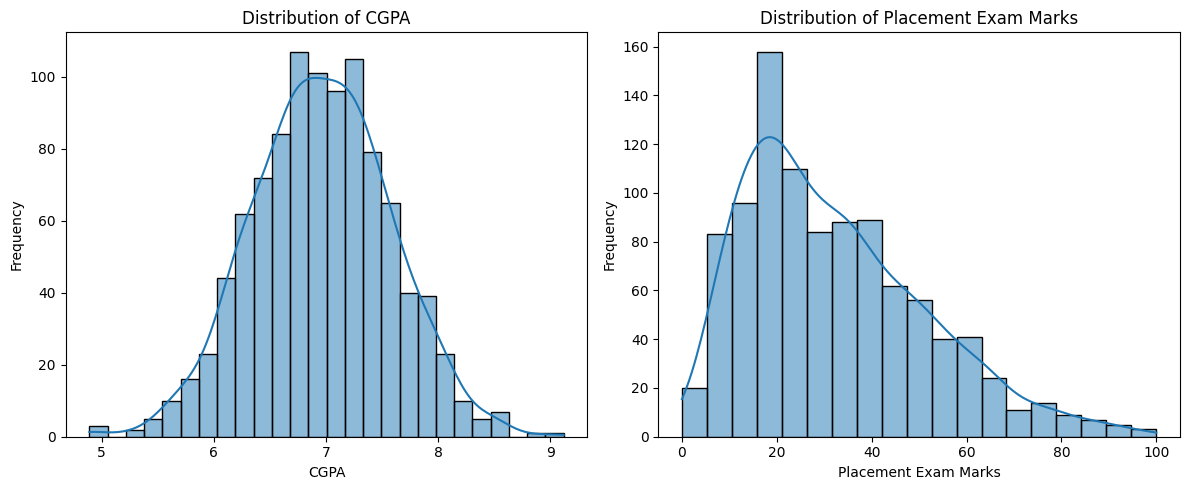

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


Text(0.5, 1.0, 'Box Plot of Placement Exam Marks')

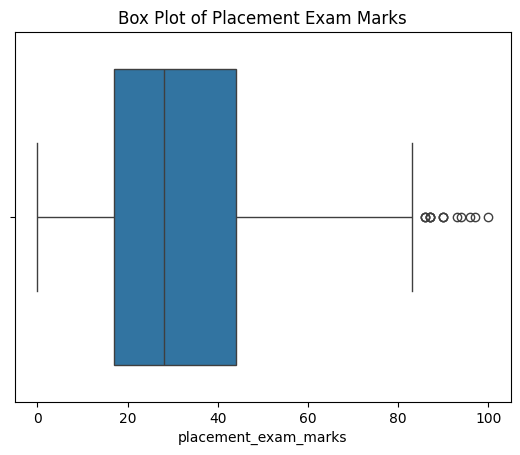

In [23]:
sns.boxplot(x='placement_exam_marks', data=df)
plt.title('Box Plot of Placement Exam Marks')

NOTE : Since this is a right skewed data, the outliers lie on the right side

In [24]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [25]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [26]:
lower_limit = percentile25 - 1.5 * iqr
upper_limit = percentile75 + 1.5 * iqr

# Finding Outliers

In [27]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# Trimming

In [28]:
new_df = df[df['placement_exam_marks'] < upper_limit]

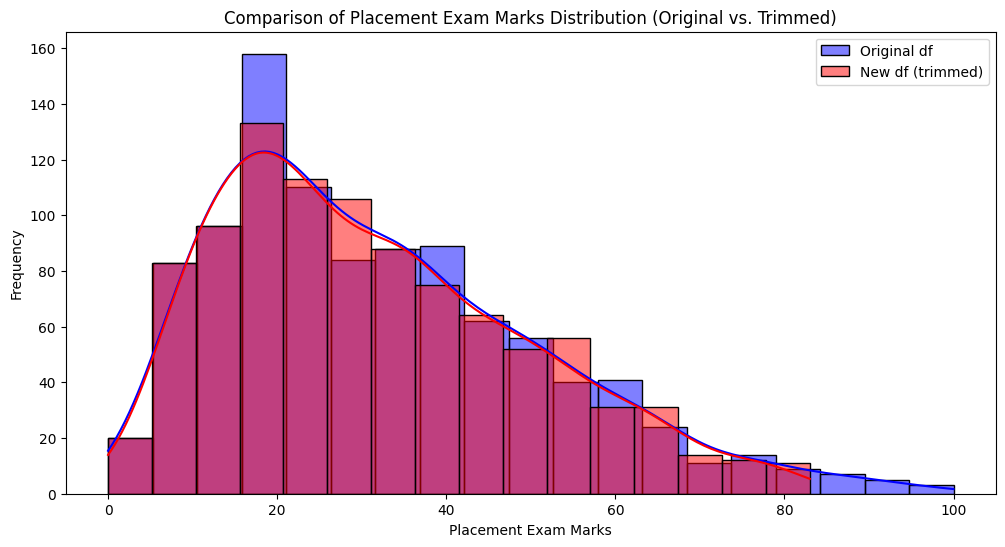

In [29]:
plt.figure(figsize=(12, 6))
sns.histplot(df['placement_exam_marks'], kde=True, label='Original df', color='blue', alpha=0.5)
sns.histplot(new_df['placement_exam_marks'], kde=True, label='New df (trimmed)', color='red', alpha=0.5)
plt.title('Comparison of Placement Exam Marks Distribution (Original vs. Trimmed)')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')
plt.legend()
plt.show()

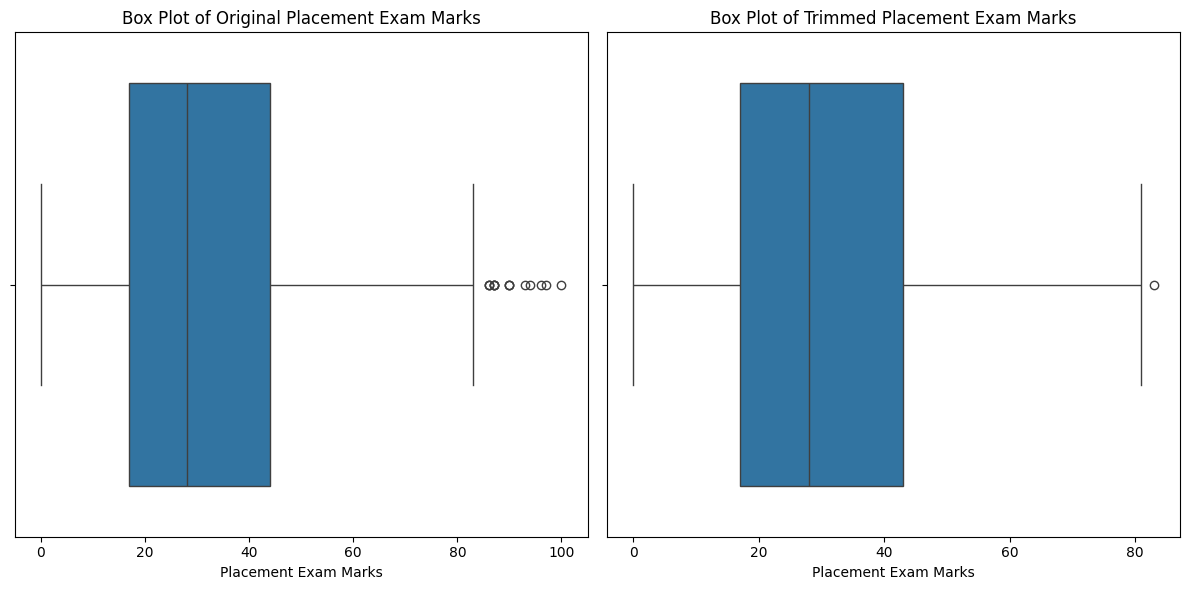

In [30]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Box Plot of Original Placement Exam Marks')
plt.xlabel('Placement Exam Marks')

plt.subplot(1, 2, 2)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.title('Box Plot of Trimmed Placement Exam Marks')
plt.xlabel('Placement Exam Marks')

plt.tight_layout()
plt.show()

# Capping

np.where syntax - np.where(condition, true, false)

In [31]:
new_df_cap = new_df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)


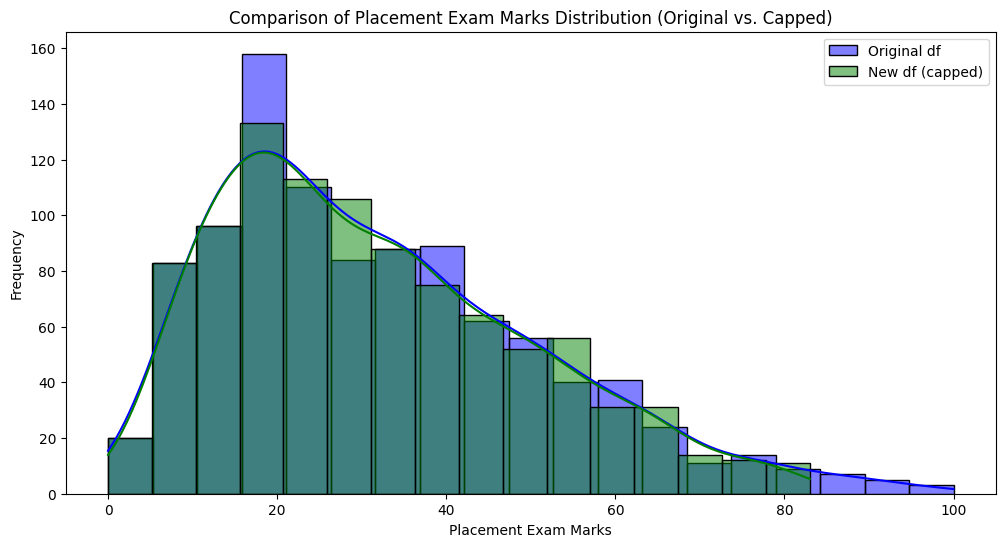

In [32]:
plt.figure(figsize=(12, 6))
sns.histplot(df['placement_exam_marks'], kde=True, label='Original df', color='blue', alpha=0.5)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True, label='New df (capped)', color='green', alpha=0.5)
plt.title('Comparison of Placement Exam Marks Distribution (Original vs. Capped)')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')
plt.legend()
plt.show()

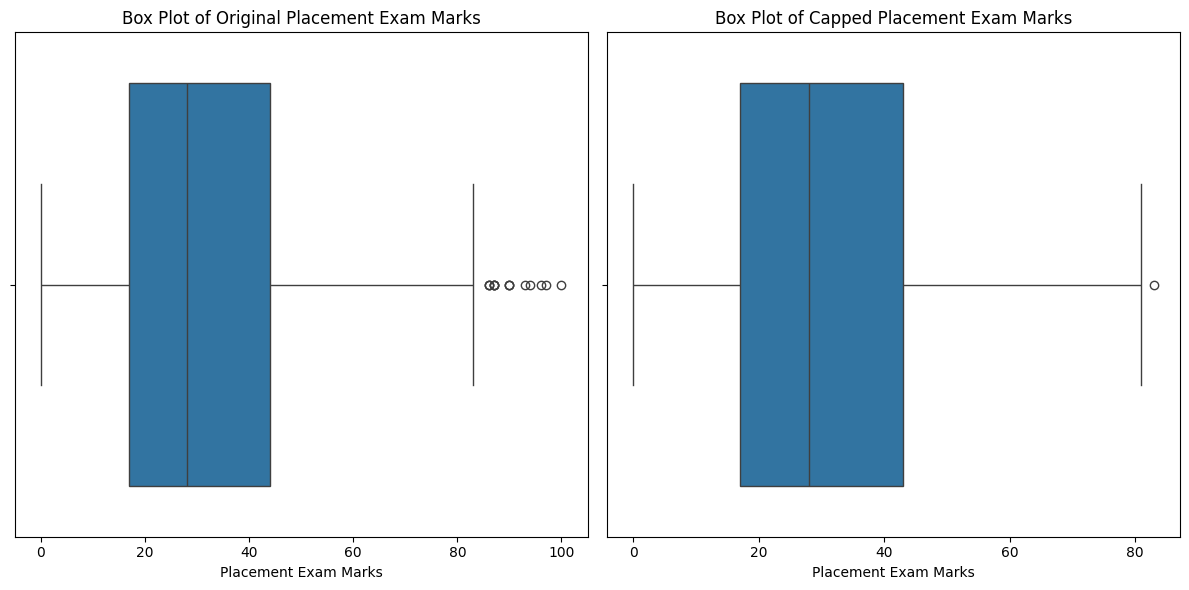

In [33]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Box Plot of Original Placement Exam Marks')
plt.xlabel('Placement Exam Marks')

plt.subplot(1, 2, 2)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.title('Box Plot of Capped Placement Exam Marks')
plt.xlabel('Placement Exam Marks')

plt.tight_layout()
plt.show()